## Training an Agent

This page provides a short outline of how to train an agent for a Gymnasium environment, in particular, we will use a tabular based Q-learning to solve the Blackjack v1 environment. For a full complete version of this tutorial and more training tutorials for other environments and algorithm, see this. Please read basic usage before reading this page. Before we implement any code, here is an overview of Blackjack and Q-learning.

## Executing an Action

After receiving our first observation, we are only going to use theenv.step(action) function to interact with the environment. This function takes an action as input and executes it in the environment. Because that action changes the state of the environment, it returns four useful variables to us. These are:

- next observation: This is the observation that the agent will receive after taking the action.

- reward: This is the reward that the agent will receive after taking the action.

- terminated: This is a boolean variable that indicates whether or not the environment has terminated, i.e., ended due to an internal condition.

- truncated: This is a boolean variable that also indicates whether the episode ended by early truncation, i.e., a time limit is reached.

- info: This is a dictionary that might contain additional information about the environment.

The next observation, reward, terminated and truncated variables are self-explanatory, but the info variable requires some additional explanation. This variable contains a dictionary that might have some extra information about the environment, but in the Blackjack-v1 environment you can ignore it. For example in Atari environments the info dictionary has a ale.lives key that tells us how many lives the agent has left. If the agent has 0 lives, then the episode is over.

Note that it is not a good idea to call env.render() in your training loop because rendering slows down training by a lot. Rather try to build an extra loop to evaluate and showcase the agent after training.

## Building an Agent

Let’s build a Q-learning agent to solve Blackjack! We’ll need some functions for picking an action and updating the agents action values. To ensure that the agents explores the environment, one possible solution is the epsilon-greedy strategy, where we pick a random action with the percentage epsilon and the greedy action (currently valued as the best) 1 - epsilon.

In [2]:
from collections import defaultdict
import gymnasium as gym
import numpy as np

class BlackjackAgent:
    def __init__(
        self,
        env: gym.Env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        """Initialize a Reinforcement Learning agent with an empty dictionary
        of state-action values (q_values), a learning rate and an epsilon.

        Args:
            env: The training environment
            learning_rate: The learning rate
            initial_epsilon: The initial epsilon value
            epsilon_decay: The decay for epsilon
            final_epsilon: The final epsilon value
            discount_factor: The discount factor for computing the Q-value
        """
        self.env = env
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))

        self.lr = learning_rate
        self.discount_factor = discount_factor

        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        self.training_error = []

    def get_action(self, obs: tuple[int, int, bool]) -> int:
        """
        Returns the best action with probability (1 - epsilon)
        otherwise a random action with probability epsilon to ensure exploration.
        """
        # with probability epsilon return a random action to explore the environment
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        # with probability (1 - epsilon) act greedily (exploit)
        else:
            return int(np.argmax(self.q_values[obs]))

    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        """Updates the Q-value of an action."""
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        temporal_difference = (
            reward + self.discount_factor * future_q_value - self.q_values[obs][action]
        )

        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

## Training the Agent

To train the agent, we will let the agent play one episode (one complete game is called an episode) at a time and update its Q-value after each action taken during the episode. The agent will have to experience a lot of episodes to explore the env sufficiently.

##

In [4]:
# hyperparameters
learning_rate = 0.01
n_episodes = 100_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

env = gym.make("Blackjack-v1", sab=False)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = BlackjackAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon
)

Info: The current hyperparameters are set to quickly train a decent agent. If you want to converge to the optimal policy, try increasing the `n_episodes` by 10x and lower the lr.

In [14]:
from tqdm import tqdm

for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False

    # play one episode
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action=action)

        # update the agent
        agent.update(obs, action, reward, terminated, next_obs)

        # update if the env is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()

100%|██████████| 100000/100000 [31:57<00:00, 52.16it/s]   


You can use `plt` to visualize the training reward and length

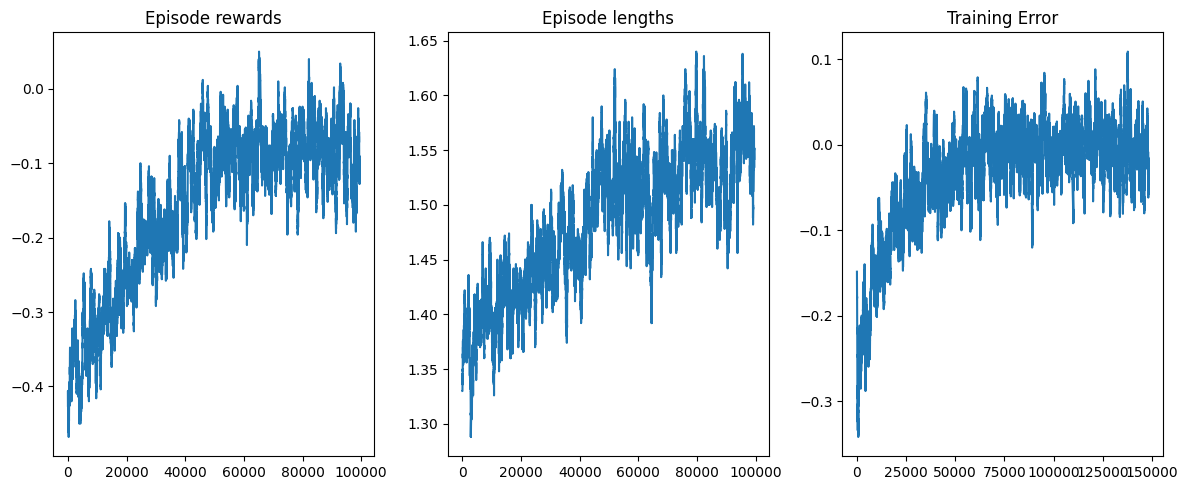

In [7]:
from matplotlib import pyplot as plt

def get_moving_avgs(arr, window, convolution_mode):
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over a 500 episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)

axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)

axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
plt.tight_layout()
plt.show()

In [10]:
print(f"obs space: {env.observation_space}")
print(f"act space: {env.action_space}")

obs space: Tuple(Discrete(32), Discrete(11), Discrete(2))
act space: Discrete(2)


In [12]:
print(f"q value: {len(agent.q_values)}")
agent.q_values

q value: 380


defaultdict(<function __main__.BlackjackAgent.__init__.<locals>.<lambda>()>,
            {(19, 10, 0): array([-0.06416358, -0.77846251]),
             (30, 10, 0): array([0., 0.]),
             (20, 10, 0): array([ 0.46071166, -0.84813004]),
             (25, 9, 0): array([0., 0.]),
             (17, 9, 0): array([-0.51401194, -0.50963857]),
             (16, 10, 0): array([-0.68024554, -0.5297378 ]),
             (15, 1, 1): array([-0.14670087, -0.12941208]),
             (16, 7, 0): array([-0.49853845, -0.47820076]),
             (25, 1, 0): array([0., 0.]),
             (16, 1, 0): array([-0.69146602, -0.61978796]),
             (14, 1, 1): array([-0.11253871, -0.06137569]),
             (21, 9, 0): array([ 0.91384329, -0.50016297]),
             (12, 9, 0): array([-0.41350378, -0.28475323]),
             (31, 9, 0): array([0., 0.]),
             (19, 6, 0): array([ 0.46738862, -0.50820898]),
             (13, 6, 0): array([-0.17884977, -0.26226389]),
             (18, 1, 1): array(